In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
## Load required libraries and combine datasets for era comparison
wrapped_2025 = pd.read_csv("/Users/shreyas/PycharmProjects/Spotify/Data/spotify_wrapped_2025_top50_songs.csv")
alltime_top100 = pd.read_csv("/Users/shreyas/PycharmProjects/Spotify/Data/spotify_alltime_top100_songs.csv")
wrapped_2025['era'] = '2025'
alltime_top100['era'] = 'all-time'
common_columns = ['song_title', 'artist', 'primary_genre', 'bpm', 'release_year',
                  'artist_country', 'explicit', 'danceability', 'energy',
                  'valence', 'acousticness', 'era']
df_2025 = wrapped_2025[common_columns]
df_alltime = alltime_top100[common_columns]
df_combined = pd.concat([df_2025, df_alltime], ignore_index=True)
print(f"Combined dataset shape: {df_combined.shape}")
print(f"\nEra breakdown:\n{df_combined['era'].value_counts()}")
print(f"\nFirst few rows:\n{df_combined.head()}")

Combined dataset shape: (150, 12)

Era breakdown:
era
all-time    100
2025         50
Name: count, dtype: int64

First few rows:
             song_title                  artist primary_genre  bpm  \
0      Die With A Smile  Lady Gaga & Bruno Mars           Pop  120   
1                  APT.       ROSE & Bruno Mars     K-Pop/Pop  145   
2              Espresso       Sabrina Carpenter           Pop  104   
3  Please Please Please       Sabrina Carpenter           Pop  107   
4                 Taste       Sabrina Carpenter           Pop  117   

   release_year artist_country  explicit  danceability  energy  valence  \
0          2024            USA     False          0.72    0.68     0.55   
1          2024    South Korea     False          0.86    0.79     0.88   
2          2024            USA     False          0.80    0.73     0.96   
3          2024            USA     False          0.70    0.66     0.87   
4          2024            USA      True          0.78    0.70     0.82   


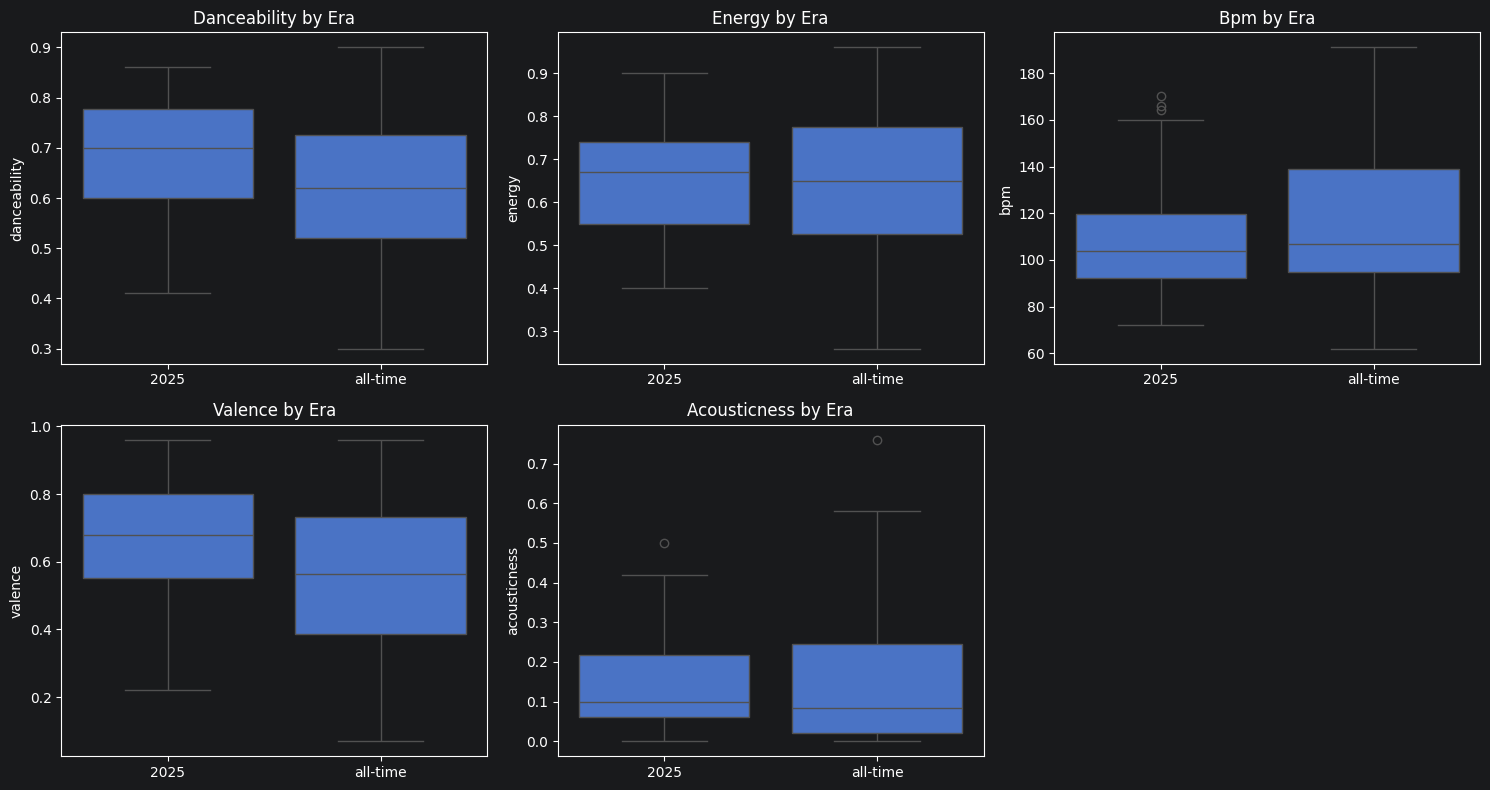

In [2]:
## Visualize the distributions of audio features across both eras using boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
features_to_plot = ['danceability', 'energy', 'bpm', 'valence', 'acousticness']
for idx, feature in enumerate(features_to_plot):

    sns.boxplot(data=df_combined, x='era', y=feature, ax=axes[idx])
    axes[idx].set_title(f'{feature.capitalize()} by Era')
    axes[idx].set_ylabel(feature)
    axes[idx].set_xlabel('')
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

In [3]:
##Calculate mean values, then compute differences and percent changes
means_by_era = df_combined.groupby('era')[['danceability', 'energy', 'bpm', 'valence', 'acousticness']].mean()
print("MEANS BY ERA:")
print(means_by_era)
print("\n" + "="*50)
difference = means_by_era.loc['2025'] - means_by_era.loc['all-time']
print("\nDIFFERENCE (2025 - all-time):")
print(difference)
print("\n" + "="*50)
pct_change = (difference / means_by_era.loc['all-time']) * 100
print("\nPERCENT CHANGE:")
print(pct_change.round(2))

MEANS BY ERA:
          danceability  energy     bpm  valence  acousticness
era                                                          
2025            0.6816  0.6468  109.80   0.6656        0.1522
all-time        0.6135  0.6361  115.78   0.5506        0.1534


DIFFERENCE (2025 - all-time):
danceability    0.0681
energy          0.0107
bpm            -5.9800
valence         0.1150
acousticness   -0.0012
dtype: float64


PERCENT CHANGE:
danceability    11.10
energy           1.68
bpm             -5.16
valence         20.89
acousticness    -0.78
dtype: float64


In [4]:
## Perform independent samples t-tests to determine if differences are statistically significant
from scipy.stats import ttest_ind
era_2025 = df_combined[df_combined['era'] == '2025']
era_alltime = df_combined[df_combined['era'] == 'all-time']
features = ['danceability', 'energy', 'bpm', 'valence', 'acousticness']
print("TEST RESULTS\n")
print(f"{'Feature':<15} {'t-statistic':<12} {'p-value':<12} {'Significant?':<15}")
print("-" * 55)
for feature in features:
    t_stat, p_value = ttest_ind(era_2025[feature], era_alltime[feature])
    significant = "YES (p < 0.05)" if p_value < 0.05 else "NO (p > 0.05)"
    print(f"{feature:<15} {t_stat:<12.4f} {p_value:<12.6f} {significant:<15}")

TEST RESULTS

Feature         t-statistic  p-value      Significant?   
-------------------------------------------------------
danceability    2.9283       0.003948     YES (p < 0.05) 
energy          0.4092       0.682954     NO (p > 0.05)  
bpm             -1.2171      0.225490     NO (p > 0.05)  
valence         2.9938       0.003230     YES (p < 0.05) 
acousticness    -0.0455      0.963782     NO (p > 0.05)  


In [5]:
## Calculate Cohen's d effect sizes to measure the practical significance
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std
print("EFFECT SIZES (Cohen's d)\n")
print(f"{'Feature':<15} {'Cohen\'s d':<12} {'Interpretation':<30}")
print("-" * 60)
features = ['danceability', 'energy', 'bpm', 'valence', 'acousticness']
for feature in features:
    d = cohens_d(era_2025[feature], era_alltime[feature])
    # Interpretation
    if abs(d) < 0.2:
        interp = "Negligible"
    elif abs(d) < 0.5:
        interp = "Small"
    elif abs(d) < 0.8:
        interp = "Medium"
    else:
        interp = "Large"
    print(f"{feature:<15} {d:<12.4f} {interp:<30}")

EFFECT SIZES (Cohen's d)

Feature         Cohen's d    Interpretation                
------------------------------------------------------------
danceability    0.5072       Medium                        
energy          0.0709       Negligible                    
bpm             -0.2108      Small                         
valence         0.5185       Medium                        
acousticness    -0.0079      Negligible                    


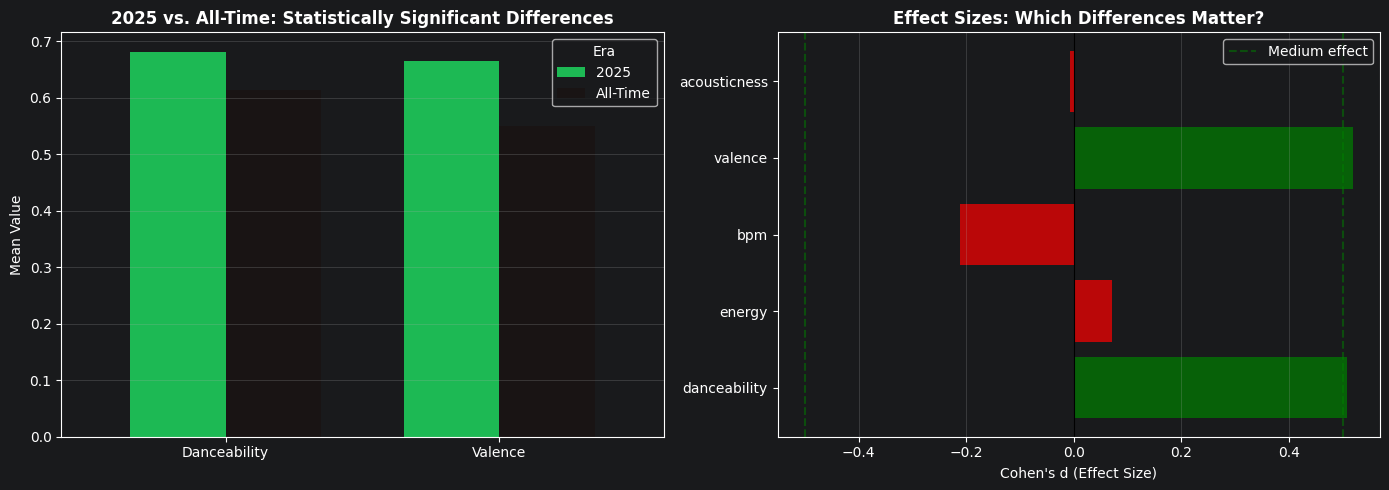

In [6]:
## Create visualization comparing significant features and effect sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
significant_features = ['danceability', 'valence']
means_sig = df_combined.groupby('era')[significant_features].mean()
means_sig.T.plot(kind='bar', ax=axes[0], color=['#1DB954', '#191414'], width=0.7)
axes[0].set_title('2025 vs. All-Time: Statistically Significant Differences', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Value')
axes[0].set_xticklabels(['Danceability', 'Valence'], rotation=0)
axes[0].legend(title='Era', labels=['2025', 'All-Time'])
axes[0].grid(axis='y', alpha=0.3)
features_all = ['danceability', 'energy', 'bpm', 'valence', 'acousticness']
effect_sizes = []
for feature in features_all:
    d = cohens_d(era_2025[feature], era_alltime[feature])
    effect_sizes.append(d)
colors = ['green' if abs(d) >= 0.5 else 'red' for d in effect_sizes]
axes[1].barh(features_all, effect_sizes, color=colors, alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='Medium effect')
axes[1].axvline(x=-0.5, color='green', linestyle='--', alpha=0.5)
axes[1].set_xlabel("Cohen's d (Effect Size)")
axes[1].set_title('Effect Sizes: Which Differences Matter?', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()